In [2]:
# Librerías
import pandas as pd
import numpy as np
import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import tensorflow as tf 
from tensorflow import keras 

In [3]:
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [4]:
#Leemos el archivo excel

df=pd.read_excel("corregido_open-meteo-37.08N6.42W2m.xlsx", header=0)
# Definimos la lista de incendios (Inicio, Fin)

incendios_info = [
    ("2017-06-12 14:00", "2017-06-13 23:59"),
    ("2017-06-24 21:00", "2017-07-04 23:59"),
    ("2019-05-13 14:00", "2019-05-15 23:59"),
    ("2019-06-01 14:00", "2019-06-06 23:59"),
    ("2019-06-07 15:00", "2019-06-07 23:59"),
    ("2019-08-27 10:00", "2019-08-27 23:59"),
    ("2019-09-12 14:00", "2019-09-15 23:59"),
    ("2021-07-24 14:00", "2021-07-28 23:59"),
    ("2021-08-17 14:00", "2021-08-19 23:59"),
    ("2022-07-25 15:00", "2022-07-28 23:59"),
    ("2022-07-25 16:00", "2022-07-28 23:59"), # Nota: Este solapa con el anterior
    ("2023-08-05 14:00", "2023-08-09 23:59")
]

# Inicializamos la columna "incendio" a "no"

df["incendio"] = 0

# Iteramos por cada incendio y marcamos las filas correspondientes
for inicio, fin in incendios_info:
    condicion = (df["time"] >= pd.to_datetime(inicio)) & (df["time"] <= pd.to_datetime(fin))
    df.loc[condicion, "incendio"] = 1

df=df.dropna(axis=0)
print(df)

                     time  temperature_2m (°C)  relative_humidity_2m (%)  \
0     2017-01-01 00:00:00                  6.5                        95   
1     2017-01-01 01:00:00                  5.7                        96   
2     2017-01-01 02:00:00                  5.0                        98   
3     2017-01-01 03:00:00                  4.8                        98   
4     2017-01-01 04:00:00                  4.7                        98   
...                   ...                  ...                       ...   
70123 2024-12-31 19:00:00                  9.4                        77   
70124 2024-12-31 20:00:00                  8.0                        83   
70125 2024-12-31 21:00:00                  7.4                        87   
70126 2024-12-31 22:00:00                  6.6                        88   
70127 2024-12-31 23:00:00                  5.9                        89   

       surface_pressure (hPa)  wind_speed_10m (km/h)  wind_direction_10m (°)  \
0      

In [5]:
# Contamos los missing values
df.isnull().sum()

time                        0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
surface_pressure (hPa)      0
wind_speed_10m (km/h)       0
wind_direction_10m (°)      0
wind_speed_100m (km/h)      0
wind_direction_100m (°)     0
wind_gusts_10m (km/h)       0
incendio                    0
dtype: int64

Eliminamos las primeras filas porque contienen la información de la localización y no nos interesa para entrenar los datos. También quitamos los valores faltantes.

In [6]:
df=df.dropna(axis=0) #axis=0 elimina filas, axis=1 columnas donde valores ausentes en algunas filas

Ya hemos limpiado los datos de valores faltantes, ahora vamos a ver si hay outliers.


In [7]:
df.describe()

,time,temperature_2m (°C),relative_humidity_2m (%),surface_pressure (hPa),wind_speed_10m (km/h),wind_direction_10m (°),wind_speed_100m (km/h),wind_direction_100m (°),wind_gusts_10m (km/h),incendio
count,70128,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000
mean,2020-12-31 23:30:00,18.543586,67.785150,1017.403385,10.258887,191.826474,17.257692,192.485598,21.659895,0.013133
min,2017-01-01 00:00:00,-1.900000,4.000000,986.200000,0.000000,1.000000,0.000000,1.000000,1.400000,0.000000
25%,2019-01-01 11:45:00,13.300000,51.000000,1013.700000,6.600000,72.000000,10.900000,77.000000,12.600000,0.000000
50%,2020-12-31 23:30:00,18.100000,70.000000,1016.500000,9.100000,229.000000,17.100000,227.000000,19.100000,0.000000
75%,2023-01-01 11:15:00,23.300000,87.000000,1021.000000,13.100000,270.000000,22.500000,268.000000,28.400000,0.000000
max,2024-12-31 23:00:00,44.400000,100.000000,1038.200000,47.900000,360.000000,76.400000,360.000000,108.400000,1.000000
std,NaN,7.320375,21.853003,5.726889,5.377497,106.333515,8.594099,103.748582,11.253618,0.113846


In [8]:
#Creamos los vectores X e Y
X = df.drop(columns=['time', 'incendio'])
y = df['incendio']
# 3. División en entrenamiento y prueba (80% tren, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
original_column_names = list(X_train.columns)

from sklearn.preprocessing import StandardScaler


In [9]:
model = keras.models.Sequential()
model.add(keras.Input(shape=(X_train.shape[1],)))
model.add(keras.layers.Dense(32, activation="relu")) #Antes 16, 32
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(16, activation="relu")) # 8, 16
model.add(keras.layers.Dropout(0.3))
#model.add(keras.layers.Dense(8, activation="relu"))  #Nueva capa 8
model.add(keras.layers.Dense(1, activation="sigmoid")) #1 porque solo hay una clase y sigmoid porque se trata de clas. binaria


In [10]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",  # para clasificación binaria
    metrics=["recall"]
)
# Early Stopping para no entrenar épocas en vano
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [11]:
from sklearn.utils import class_weight

#Reducción de Dimensionalidad (PCA)
pca = PCA(n_components=0.95)

# Calcula los pesos automáticamente
weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(Y_train), 
                                            y=Y_train)
dict_weights = dict(enumerate(weights))


history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,  # valida 20% de train
    verbose=2,
    class_weight=dict_weights,
    callbacks=[early_stop]
)


Epoch 1/20
1403/1403 - 10s - 7ms/step - loss: 16.3263 - recall: 0.5901 - val_loss: 0.7850 - val_recall: 1.0000
Epoch 2/20
1403/1403 - 6s - 4ms/step - loss: 0.9969 - recall: 0.8975 - val_loss: 0.7582 - val_recall: 1.0000
Epoch 3/20
1403/1403 - 6s - 4ms/step - loss: 0.9442 - recall: 0.9521 - val_loss: 0.7297 - val_recall: 1.0000
Epoch 4/20
1403/1403 - 6s - 4ms/step - loss: 0.7915 - recall: 0.9488 - val_loss: 0.7144 - val_recall: 1.0000
Epoch 5/20
1403/1403 - 10s - 7ms/step - loss: 0.7070 - recall: 0.9769 - val_loss: 0.7056 - val_recall: 1.0000
Epoch 6/20
1403/1403 - 6s - 4ms/step - loss: 0.7152 - recall: 0.8843 - val_loss: 0.7032 - val_recall: 1.0000
Epoch 7/20
1403/1403 - 6s - 4ms/step - loss: 0.7022 - recall: 0.8959 - val_loss: 0.7008 - val_recall: 1.0000
Epoch 8/20
1403/1403 - 6s - 4ms/step - loss: 0.6990 - recall: 0.8165 - val_loss: 0.7016 - val_recall: 1.0000
Epoch 9/20
1403/1403 - 6s - 4ms/step - loss: 0.7330 - recall: 0.8413 - val_loss: 0.7015 - val_recall: 1.0000
Epoch 10/20
1403

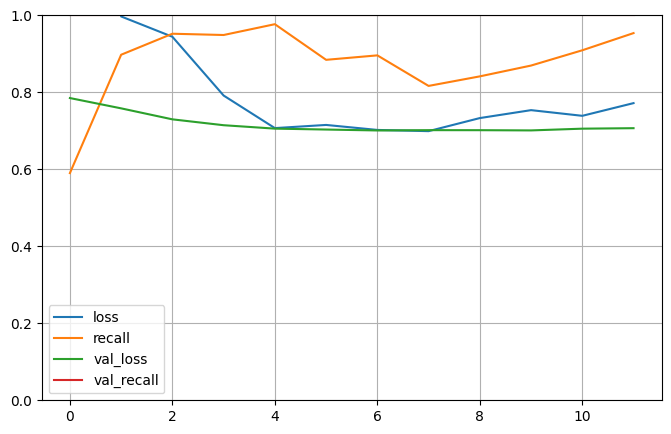

In [12]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [13]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f"Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")


Loss: 0.7008, Accuracy: 1.0000


In [14]:

from sklearn.metrics import f1_score

Y_pred = (model.predict(X_test) > 0.5).astype(int)

# Calcular F1 score
score = f1_score(Y_test, Y_pred)
print("F1 Score:", score)


439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
F1 Score: 0.024228764614734468


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)
print(cm)


[[    0 13854]
 [    0   172]]


In [16]:
pip install scikeras

Note: you may need to restart the kernel to use updated packages.


In [17]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

In [18]:
# Definimos una función que crea el modelo (necesaria para el wrapper)
from tensorflow import keras
from tensorflow.keras import layers

def create_model(hidden_layers=1, neurons=32, dropout_rate=0.0, meta=None):
    tf.random.set_seed(42) 
    model = keras.models.Sequential()
    
    input_dim = meta["n_features_in_"]
    model.add(keras.Input(shape=(input_dim,)))
    
    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons, activation="relu"))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, seed=42))
    
    model.add(layers.Dense(1, activation="sigmoid"))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.Recall(name="recall")]
    )
    
    return model

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',           # <--- CAMBIA ESTO (de val_loss a loss)
    patience=5, 
    restore_best_weights=True # Muy importante para quedarse con el mejor punto
)
# Creamos el objeto estimador
model_wrapper = KerasClassifier(
    model=create_model,
    verbose=0,
    callbacks=[early_stop]
)

In [19]:
print(model_wrapper.get_params().keys())

dict_keys(['model', 'build_fn', 'warm_start', 'random_state', 'optimizer', 'loss', 'metrics', 'batch_size', 'validation_batch_size', 'verbose', 'callbacks', 'validation_split', 'shuffle', 'run_eagerly', 'epochs', 'class_weight'])


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('mlp', model_wrapper)
])
# Definimos qué queremos probar 
param_grid = {'pca__n_components':[0.9, 0.95],
              'mlp__model__hidden_layers': [1, 2], # Probar con 1 o 2 capas ocultas 
              'mlp__model__neurons': [16, 32], # Probar diferentes anchos 16, 32
              'mlp__batch_size': [16, 32], # Probar diferentes tamaños de lote 16,32 
              'mlp__model__dropout_rate': [0.0, 0.1],
              'mlp__epochs': [20]
             } 
from sklearn.model_selection import GridSearchCV 
# Configuramos la búsqueda aleatoria 
grid_search = GridSearchCV( estimator= pipeline, 
                           param_grid=param_grid, 
                           cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
                           scoring='f1', # Optimizamos para Recall como querías 
                           verbose=2,
                           n_jobs=1
                          ) # Ejecutar búsqueda (usa class_weight si tu dataset sigue desbalanceado) 
grid_result = grid_search.fit(X_train, Y_train, 
                              mlp__class_weight=dict_weights,
                              mlp__validation_split=0.2) 
# 4. Ver resultados del mejor modelo print(f"Mejor Recall: {grid_result.best_score_}") 
print(f"Mejores parámetros: {grid_result.best_params_}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.9; total time= 2.5min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.9; total time= 2.5min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.9; total time= 2.5min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.95; total time= 2.6min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.95; total time= 2.4min
[CV] END mlp__batch_size=16, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__

[CV] END mlp__batch_size=32, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.9; total time=  37.8s
[CV] END mlp__batch_size=32, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.9; total time=  37.6s
[CV] END mlp__batch_size=32, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.9; total time=  30.1s
[CV] END mlp__batch_size=32, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.95; total time=  40.1s
[CV] END mlp__batch_size=32, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.95; total time=  13.2s
[CV] END mlp__batch_size=32, mlp__epochs=20, mlp__model__dropout_rate=0.0, mlp__model__hidden_layers=1, mlp__model__neurons=16, pca__n_components=0.

Threshold óptimo: 0.7097788
Precision: 0.06482155863073562
Recall: 0.5174418604651163
[[10601  3253]
 [   32   140]]


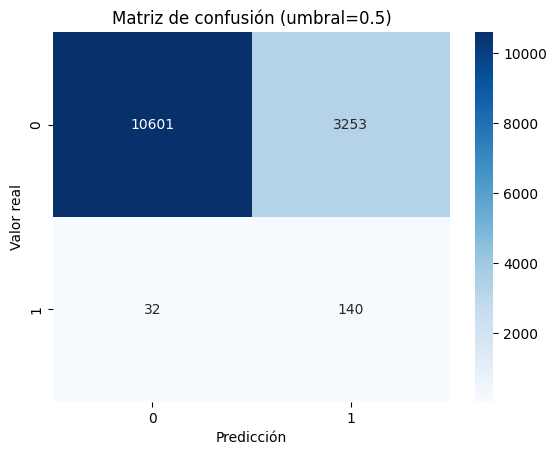

In [22]:
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_recall_curve

# 🔹 1. Probabilidades (IMPORTANTÍSIMO)
# Probabilidades de clase positiva
y_prob = grid_result.best_estimator_.predict_proba(X_test)[:, 1]

# Curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(Y_test, y_prob)

# Buscar threshold que mantenga Recall >= 0.90 y maximice Precision
target_recall = 0.5
idx = np.where(recalls >= target_recall)[0]  # todos los thresholds con Recall >= 0.9
best_idx = idx[np.argmax(precisions[idx])]    # entre ellos, escoger el que da mayor Precision
best_threshold = thresholds[best_idx]

print("Threshold óptimo:", best_threshold)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])

# Aplicar threshold
Y_pred = (y_prob >= 0.5).astype(int)
threshold=0.5
# Matriz de confusión final
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm)
# 🔹 5. Visualización
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(f"Matriz de confusión (umbral={threshold})")
plt.show()

In [23]:
print(dict_weights)

{0: np.float64(0.5067656676241576), 1: np.float64(37.45126835781041)}


In [24]:
print(np.mean(Y_train))
print(np.mean(Y_test))

0.013350682685109265
0.012262940253814344


Vemos que F1 Score es muy bajo ya que nuestro dataset está muy desbalanceado, por tanto, vamos a usar class weight para que la clase minoritaria(Incendio) tenga más peso.

In [25]:
from sklearn.metrics import precision_score, recall_score

Y_pred = (grid_result.best_estimator_.predict(X_test) > 0.1).astype(int)


print("Recall:", recall_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("F1 Score:", f1_score(Y_test, Y_pred))

Recall: 0.813953488372093
Precision: 0.0412614205717654
F1 Score: 0.0785413744740533


[[10601  3253]
 [   32   140]]
Min: 1.9191158e-35
Max: 0.996526
Ejemplo: [6.6338050e-01 2.2463357e-01 7.5923377e-01 4.4580692e-01 2.8523496e-27
 1.0515358e-01 1.4827850e-09 7.3197442e-01 3.9811417e-01 1.6563015e-05]


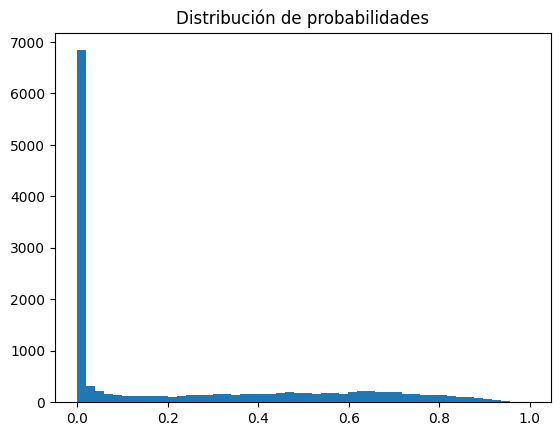


Threshold 0.1
FP: 6184, FN: 5

Threshold 0.2
FP: 5570, FN: 5

Threshold 0.5
FP: 3253, FN: 32

Threshold 0.6
FP: 2407, FN: 57


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)
print(cm)

y_prob = grid_result.best_estimator_.predict_proba(X_test)[:, 1]

print("Min:", y_prob.min())
print("Max:", y_prob.max())
print("Ejemplo:", y_prob[:10])
plt.hist(y_prob, bins=50)
plt.title("Distribución de probabilidades")
plt.show()
y_prob = grid_result.best_estimator_.predict_proba(X_test)[:, 1]

for t in [0.1, 0.2, 0.5, 0.6]:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(Y_test, y_pred).ravel()
    
    print(f"\nThreshold {t}")
    print(f"FP: {fp}, FN: {fn}")

Mejor threshold (F1): 0.84466505
Precision: 0.09762532981530343
Recall: 0.21511627906976744
F1: 0.1343012661231025


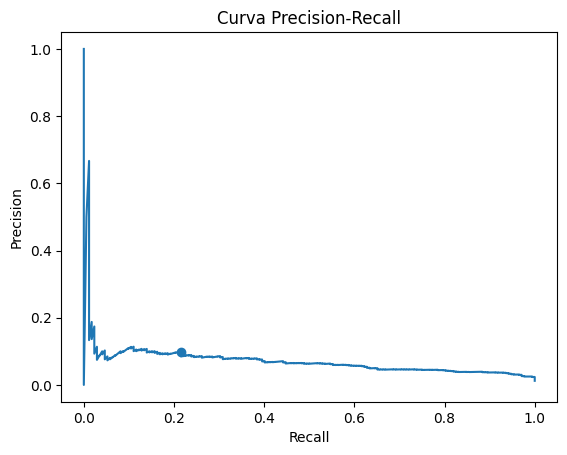

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Probabilidades
y_prob = grid_result.best_estimator_.predict_proba(X_test)[:, 1]

# Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(Y_test, y_prob)

# 🔹 Calcular F1 para cada umbral
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# 🔹 Mejor umbral según F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Mejor threshold (F1):", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])

# 📈 Gráfica Precision-Recall
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")

# Punto óptimo
plt.scatter(recall[best_idx], precision[best_idx])
plt.show()

In [28]:
# Queremos recall >= 0.90
target_recall = 0.90

idx = np.where(recall >= target_recall)[0][-1]
threshold_recall = thresholds[idx]

print("Threshold con recall >= 0.90:", threshold_recall)
print("Precision:", precision[idx])
print("Recall:", recall[idx])

Threshold con recall >= 0.90: 0.4135689
Precision: 0.037152444870565675
Recall: 0.9011627906976745


Index([48759, 48760, 48761, 48762, 48763, 48764, 48765, 48766, 48767, 48768,
       48769, 48770, 48771, 48772, 48773, 48774, 48775, 48776, 48777, 48778,
       48779, 48780, 48781, 48782, 48783, 48784, 48785, 48786, 48787, 48788,
       48789, 48790, 48791, 48792, 48793, 48794, 48795, 48796, 48797, 48798,
       48799, 48800, 48801, 48802, 48803, 48804, 48805, 48806, 48807, 48808,
       48809, 48810, 48811, 48812, 48813, 48814, 48815, 48816, 48817, 48818,
       48819, 48820, 48821, 48822, 48823, 48824, 48825, 48826, 48827, 48828,
       48829, 48830, 48831, 48832, 48833, 48834, 48835, 48836, 48837, 48838,
       48839],
      dtype='int64')


C:\Users\silvi\AppData\Local\Temp\ipykernel_28428\4205262520.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_incendio_test['fecha'] = df.loc[df_incendio_test.index, df.columns[0]]


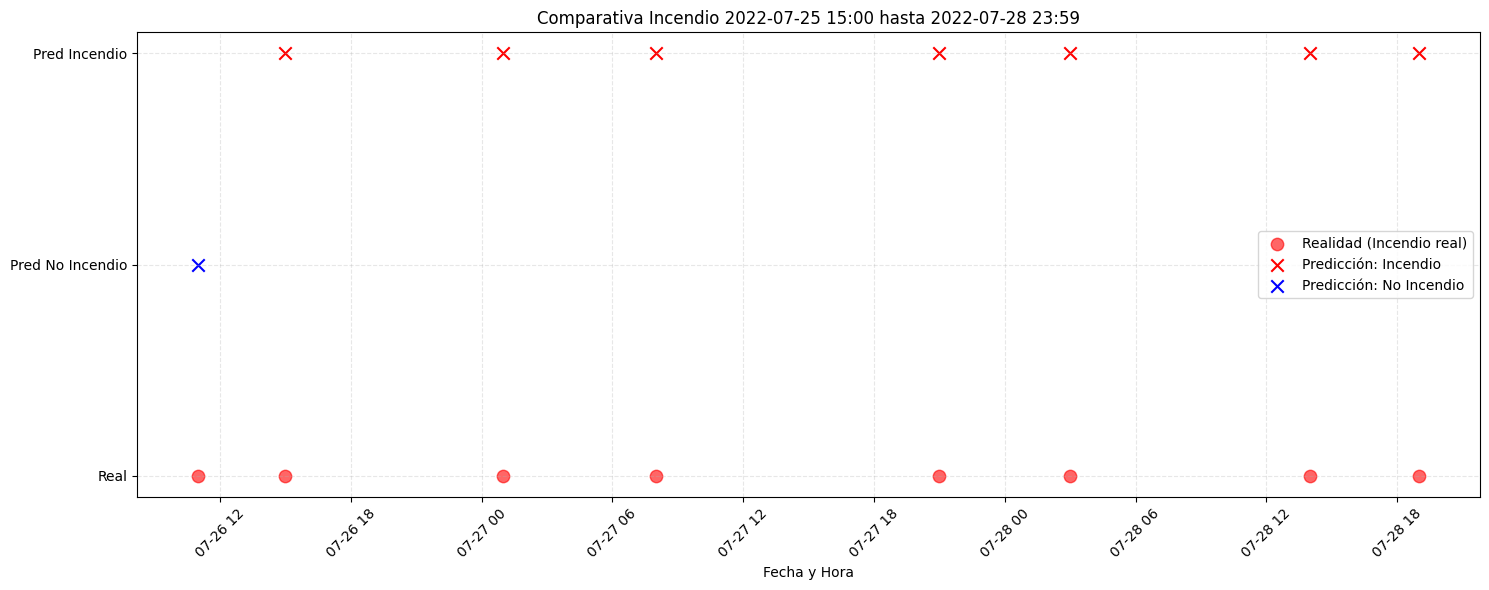

Se han detectado 7 horas del incendio de 8 horas. 


In [29]:
# 1. Buscamos los índices (los números de la izquierda) que corresponden a esas fechas
mask_incendio = (df.iloc[:, 0] >= "2022-07-25 15:00") & (df.iloc[:, 0] <= "2022-07-28 23:59")
indices_incendio = df[mask_incendio].index

print(indices_incendio)
# 2. Creamos un DataFrame de resultados uniendo y_test e y_pred_opt
# Importante: X_test conserva el índice original (ej: 71, 72...)
df_resultados = pd.DataFrame({
    'real': Y_test,
    'prediccion': Y_pred
}, index=Y_test.index)

df_resultados
# 3. Filtramos df_resultados usando solo los índices que encontramos en el paso 1
# Esto selecciona solo las filas del incendio que cayeron en tu set de TEST
df_incendio_test = df_resultados.loc[df_resultados.index.isin(indices_incendio)]

df_incendio_test

# 4. Recuperamos las fechas para el eje X
df_incendio_test['fecha'] = df.loc[df_incendio_test.index, df.columns[0]]
df_incendio_test = df_incendio_test.sort_values('fecha')
 
df_incendio_test
# --- Visualización ---
plt.figure(figsize=(15, 6))

# --- REALIDAD: siempre abajo en rojo ---
plt.scatter(
    df_incendio_test['fecha'], 
    [0]*len(df_incendio_test),   # todos abajo
    color='red', 
    label='Realidad (Incendio real)', 
    s=80, 
    alpha=0.6
)

# --- PREDICCIONES ---
# Predicción = 1 (Incendio) -> cruces rojas arriba
pred_si = df_incendio_test[df_incendio_test['prediccion'] == 1]
plt.scatter(
    pred_si['fecha'], 
    [1]*len(pred_si), 
    color='red', 
    marker='x', 
    label='Predicción: Incendio', 
    s=80
)

# Predicción = 0 (No incendio) -> cruces azules a otra altura
pred_no = df_incendio_test[df_incendio_test['prediccion'] == 0]
plt.scatter(
    pred_no['fecha'], 
    [0.5]*len(pred_no),  # altura intermedia
    color='blue', 
    marker='x', 
    label='Predicción: No Incendio', 
    s=80
)

# Ejes y estilo
plt.yticks([0, 0.5, 1], ['Real', 'Pred No Incendio', 'Pred Incendio'])
plt.title('Comparativa Incendio 2022-07-25 15:00 hasta 2022-07-28 23:59')
plt.xlabel('Fecha y Hora')
plt.grid(True, axis='both', linestyle='--', alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Finalmente, contamos cuantas horas de incendio predice bien

total_incendios_predichos = df_incendio_test['prediccion'].sum()

print(f'Se han detectado {total_incendios_predichos} horas del incendio de {len(df_incendio_test)} horas. ' )

In [30]:
from sklearn.inspection import permutation_importance

X_test_df = pd.DataFrame(X_test, columns=original_column_names)

result = permutation_importance(
    grid_search.best_estimator_, 
    X_test_df,
    Y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancia = pd.DataFrame({
    'Variable': original_column_names,
    'Importancia': result.importances_mean
}).sort_values(by='Importancia', ascending=False)

print(importancia)

                   Variable  Importancia
1  relative_humidity_2m (%)     0.079110
0       temperature_2m (°C)     0.032219
7     wind_gusts_10m (km/h)     0.031313
5    wind_speed_100m (km/h)     0.028126
3     wind_speed_10m (km/h)     0.019820
4    wind_direction_10m (°)    -0.000970
6   wind_direction_100m (°)    -0.007422
2    surface_pressure (hPa)    -0.036974


In [31]:
pca = grid_search.best_estimator_.named_steps['pca']
print(pca.n_components_)
print(pca.explained_variance_ratio_)
componentes = pd.DataFrame(
    pca.components_,
    columns=original_column_names,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print(componentes)
for i in range(pca.n_components_):
    print(f"\n🔹 PC{i+1}")
    print(componentes.iloc[i].abs().sort_values(ascending=False))

5
[0.40555618 0.23035717 0.19966232 0.09230955 0.02813484]
     temperature_2m (°C)  relative_humidity_2m (%)  surface_pressure (hPa)  \
PC1             0.278478                 -0.274935               -0.311452   
PC2             0.298212                 -0.095984               -0.220716   
PC3            -0.543677                  0.587444                0.033825   
PC4            -0.012952                 -0.339974                0.884748   
PC5             0.627577                  0.666885                0.259610   

     wind_speed_10m (km/h)  wind_direction_10m (°)  wind_speed_100m (km/h)  \
PC1               0.471279                0.250224                0.396271   
PC2              -0.345939                0.513335               -0.376419   
PC3               0.122099                0.354535                0.296648   
PC4               0.060416                0.229249                0.031179   
PC5               0.124066               -0.106097               -0.147330   

   

C:\Users\silvi\AppData\Local\Temp\ipykernel_28428\3148014879.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=componentes.columns, y=componentes.loc[pc].abs(), palette="viridis", ax=ax)
C:\Users\silvi\AppData\Local\Temp\ipykernel_28428\3148014879.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(componentes.columns, rotation=45, ha='right')
C:\Users\silvi\AppData\Local\Temp\ipykernel_28428\3148014879.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=componentes.columns, y=componentes.loc[pc].abs(), palette="viridis", ax=ax)
C:\Users\silvi\AppData\Local\Temp\ipykernel_28428\3

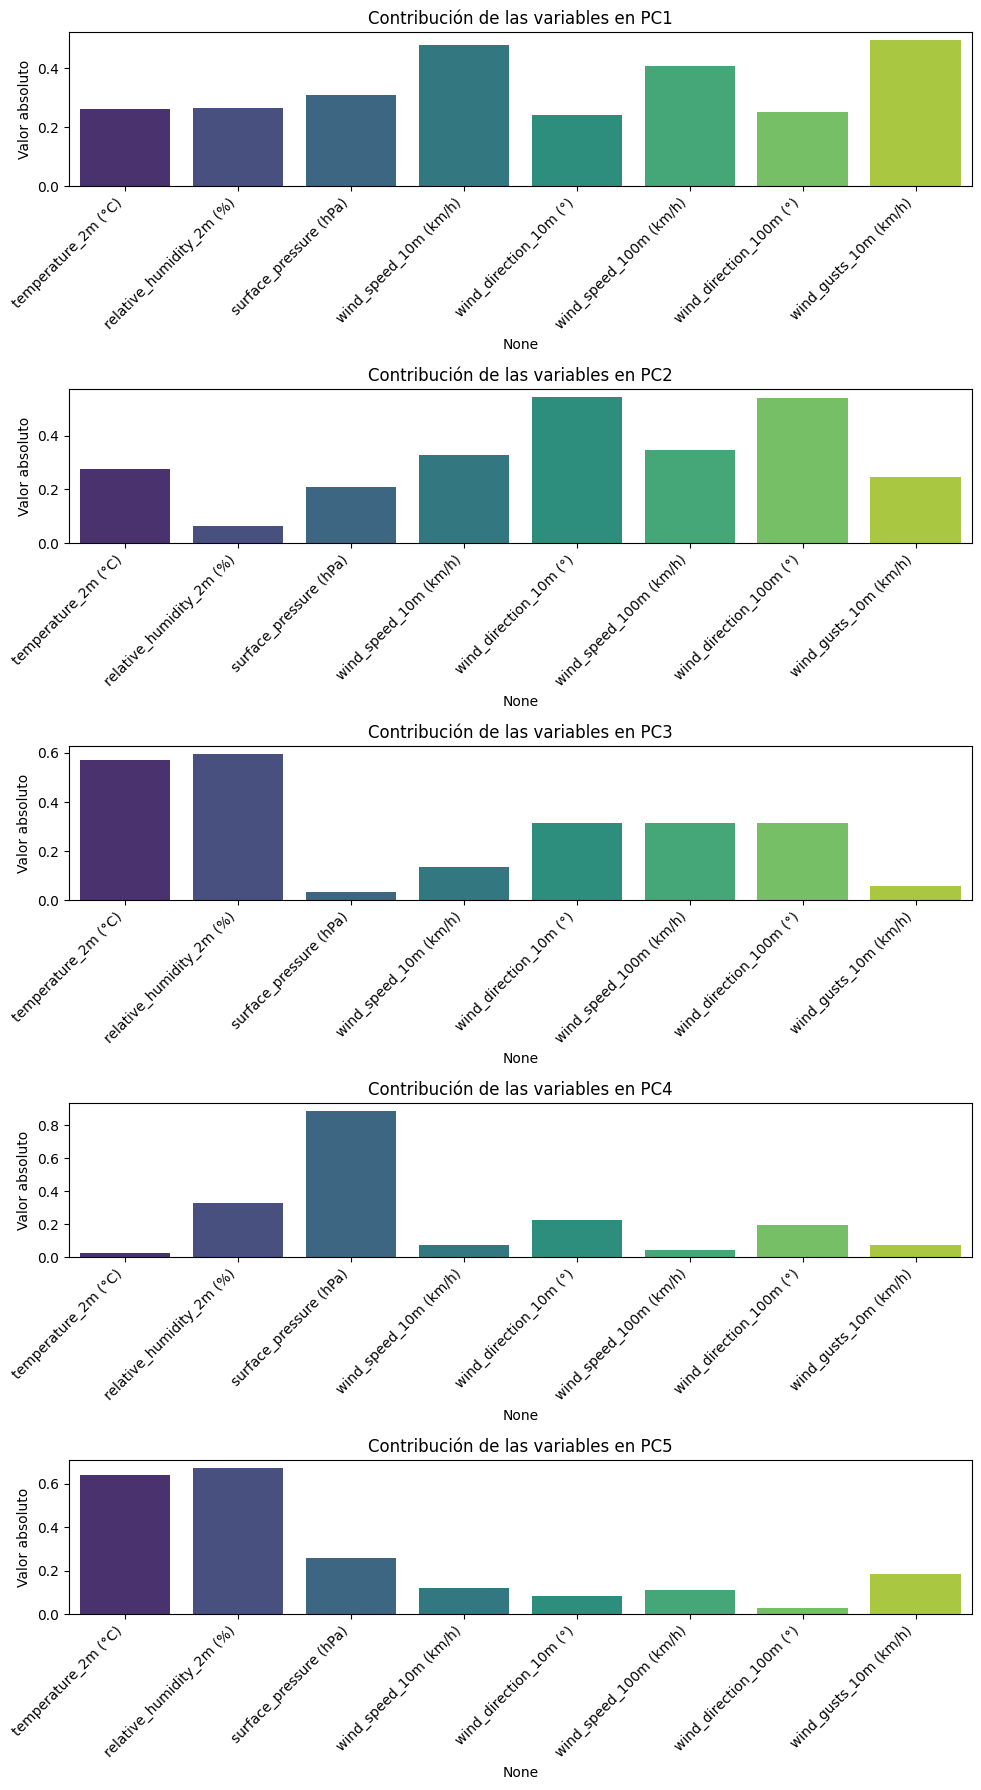

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Supongamos que ya tienes tus componentes en un DataFrame
# filas = PCs, columnas = variables originales
componentes = pd.DataFrame({
    'temperature_2m (°C)': [0.261241, 0.276168, 0.570072, 0.022746, 0.640111],
    'relative_humidity_2m (%)': [0.267073, 0.064960, 0.596969, 0.326580, 0.673916],
    'surface_pressure (hPa)': [0.308163, 0.208183, 0.035116, 0.889786, 0.258737],
    'wind_speed_10m (km/h)': [0.479759, 0.326654, 0.134273, 0.071418, 0.122382],
    'wind_direction_10m (°)': [0.240854, 0.544724, 0.315002, 0.225118, 0.083898],
    'wind_speed_100m (km/h)': [0.407753, 0.346215, 0.312667, 0.042940, 0.110018],
    'wind_direction_100m (°)': [0.252496, 0.539838, 0.314958, 0.194091, 0.026635],
    'wind_gusts_10m (km/h)': [0.497258, 0.247901, 0.056556, 0.076259, 0.185261]
}, index=[f'PC{i+1}' for i in range(5)])

# Crear gráfico
fig, axes = plt.subplots(5, 1, figsize=(10, 18))
for i, pc in enumerate(componentes.index):
    ax = axes[i]
    sns.barplot(x=componentes.columns, y=componentes.loc[pc].abs(), palette="viridis", ax=ax)
    ax.set_title(f'Contribución de las variables en {pc}')
    ax.set_ylabel('Valor absoluto')
    ax.set_xticklabels(componentes.columns, rotation=45, ha='right')
plt.tight_layout()
plt.show()

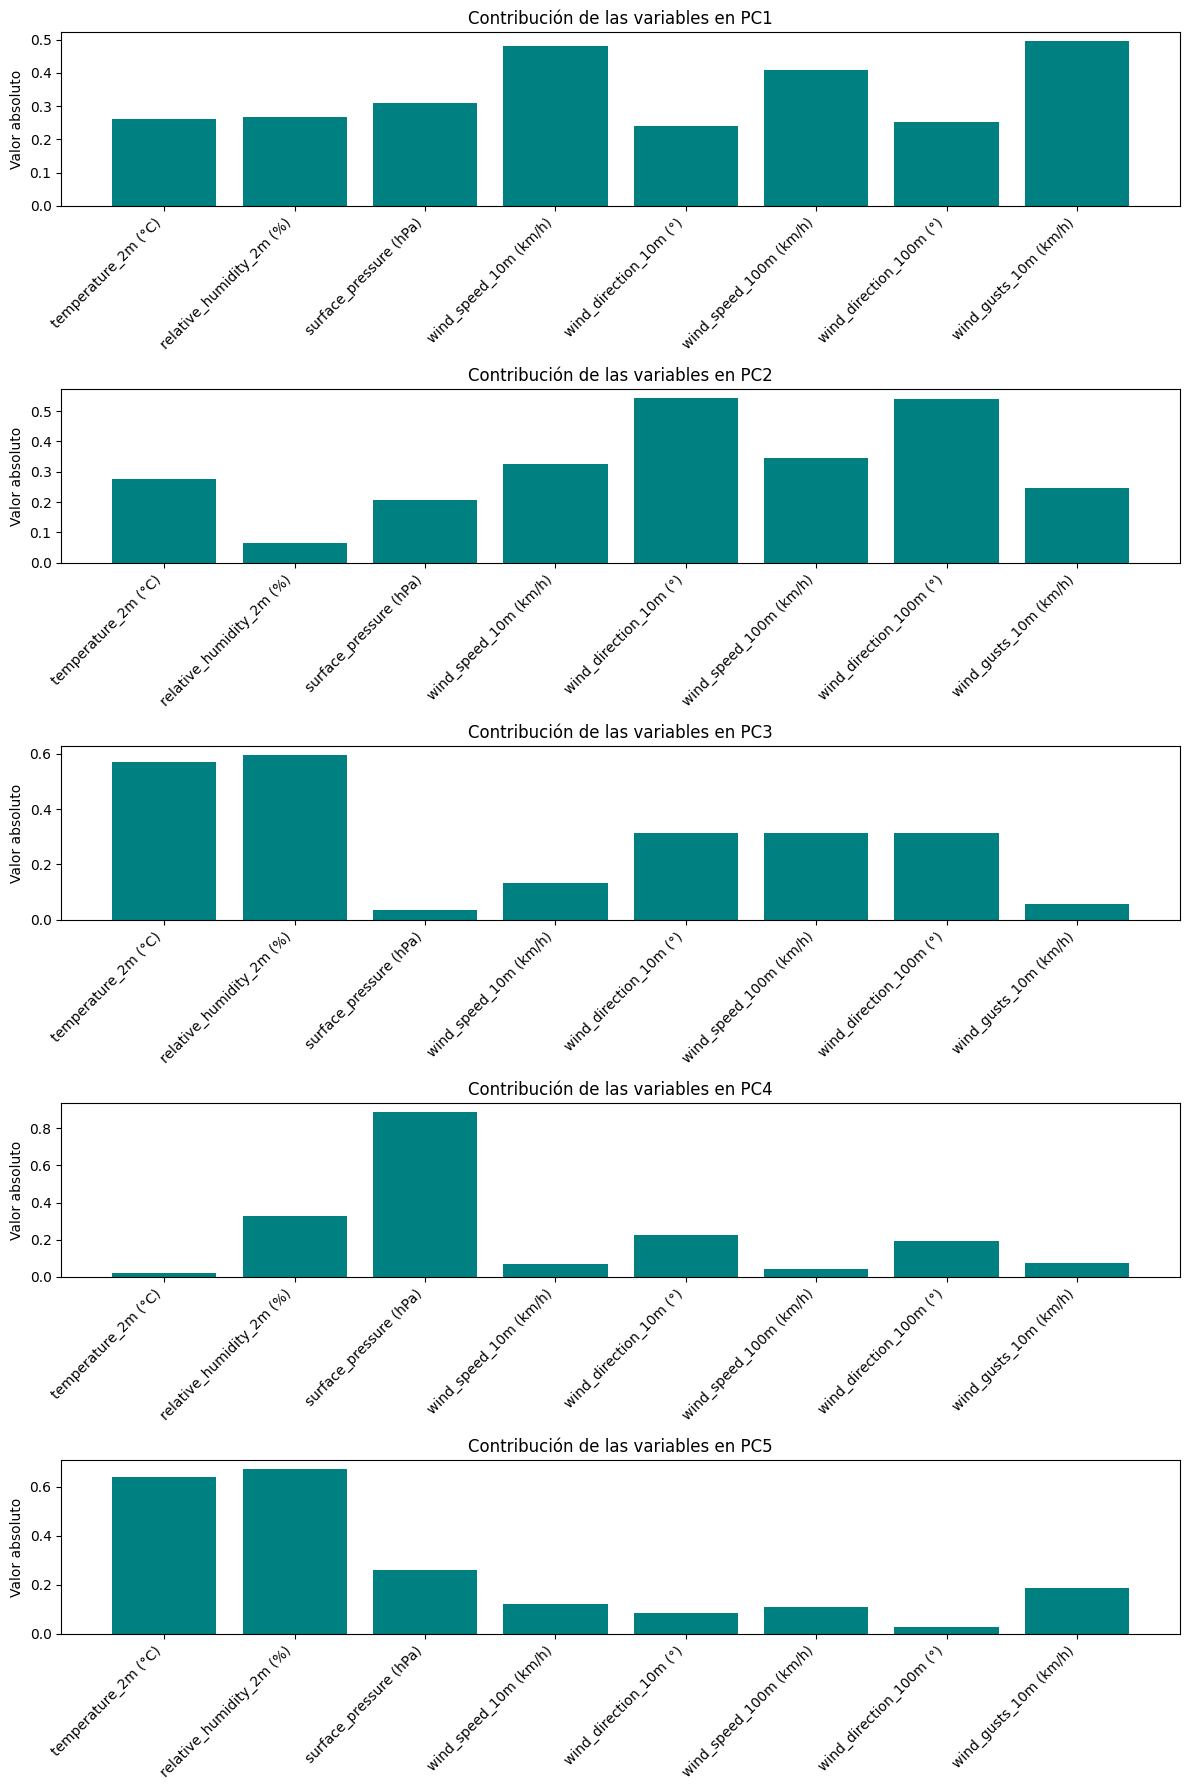

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# DataFrame con PCs
componentes = pd.DataFrame({
    'temperature_2m (°C)': [0.261241, 0.276168, 0.570072, 0.022746, 0.640111],
    'relative_humidity_2m (%)': [0.267073, 0.064960, 0.596969, 0.326580, 0.673916],
    'surface_pressure (hPa)': [0.308163, 0.208183, 0.035116, 0.889786, 0.258737],
    'wind_speed_10m (km/h)': [0.479759, 0.326654, 0.134273, 0.071418, 0.122382],
    'wind_direction_10m (°)': [0.240854, 0.544724, 0.315002, 0.225118, 0.083898],
    'wind_speed_100m (km/h)': [0.407753, 0.346215, 0.312667, 0.042940, 0.110018],
    'wind_direction_100m (°)': [0.252496, 0.539838, 0.314958, 0.194091, 0.026635],
    'wind_gusts_10m (km/h)': [0.497258, 0.247901, 0.056556, 0.076259, 0.185261]
}, index=[f'PC{i+1}' for i in range(5)])

# Gráfico
fig, axes = plt.subplots(5, 1, figsize=(12, 18))

for i, pc in enumerate(componentes.index):
    ax = axes[i]
    y = componentes.loc[pc].abs()
    x = np.arange(len(componentes.columns))
    ax.bar(x, y, color='teal')
    ax.set_title(f'Contribución de las variables en {pc}', fontsize=12)
    ax.set_ylabel('Valor absoluto', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(componentes.columns, rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

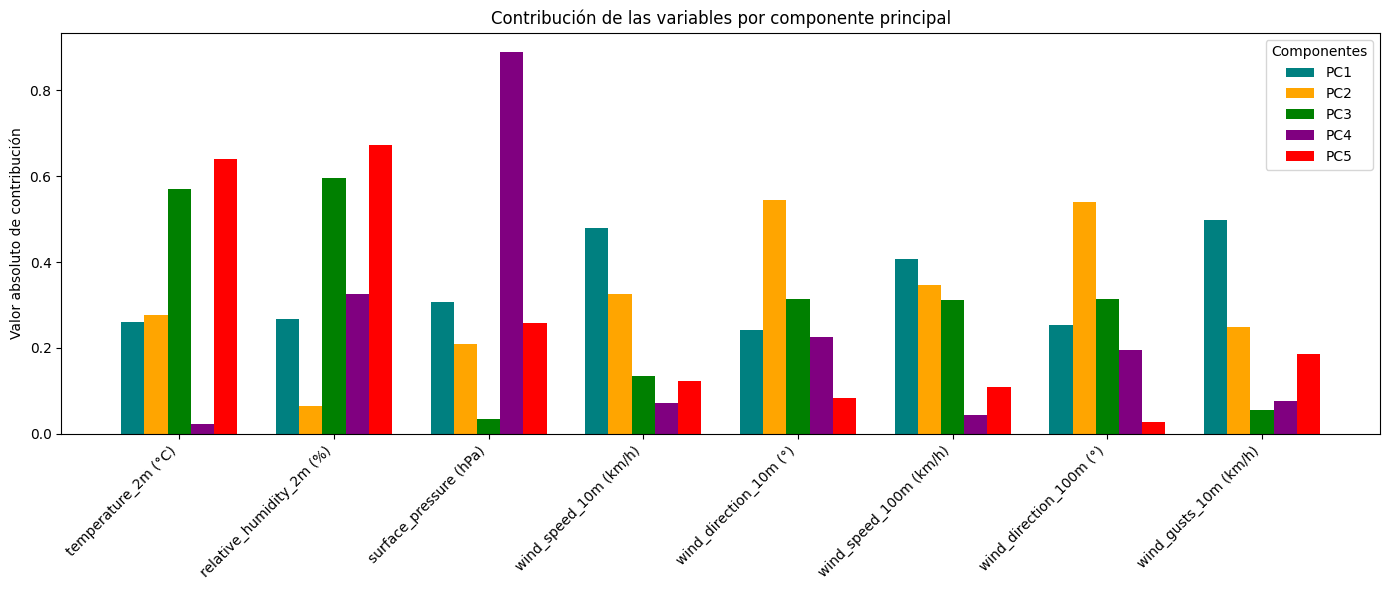

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# DataFrame con PCs
componentes = pd.DataFrame({
    'temperature_2m (°C)': [0.261241, 0.276168, 0.570072, 0.022746, 0.640111],
    'relative_humidity_2m (%)': [0.267073, 0.064960, 0.596969, 0.326580, 0.673916],
    'surface_pressure (hPa)': [0.308163, 0.208183, 0.035116, 0.889786, 0.258737],
    'wind_speed_10m (km/h)': [0.479759, 0.326654, 0.134273, 0.071418, 0.122382],
    'wind_direction_10m (°)': [0.240854, 0.544724, 0.315002, 0.225118, 0.083898],
    'wind_speed_100m (km/h)': [0.407753, 0.346215, 0.312667, 0.042940, 0.110018],
    'wind_direction_100m (°)': [0.252496, 0.539838, 0.314958, 0.194091, 0.026635],
    'wind_gusts_10m (km/h)': [0.497258, 0.247901, 0.056556, 0.076259, 0.185261]
}, index=[f'PC{i+1}' for i in range(5)])

variables = componentes.columns
n_vars = len(variables)
n_pcs = len(componentes)

x = np.arange(n_vars)  # posiciones de las variables
width = 0.15           # ancho de cada barra

fig, ax = plt.subplots(figsize=(14,6))

# Colores para cada PC
colors = ['teal', 'orange', 'green', 'purple', 'red']

for i, pc in enumerate(componentes.index):
    ax.bar(x + i*width, componentes.loc[pc].abs(), width=width, label=pc, color=colors[i])

# Etiquetas
ax.set_xticks(x + width*2)  # centrar las etiquetas
ax.set_xticklabels(variables, rotation=45, ha='right')
ax.set_ylabel('Valor absoluto de contribución')
ax.set_title('Contribución de las variables por componente principal')
ax.legend(title='Componentes')
plt.tight_layout()
plt.show()

In [36]:
import joblib

joblib.dump(grid_search.best_estimator_, 'modelo_mlp_pca.pkl')

['modelo_mlp_pca.pkl']